In [1]:
import glob
import matplotlib.pyplot as plt
import numpy as np


from sunpy.net import Fido
from sunpy.net import attrs as a

import punchbowl  # Note that this import is needed to register PUNCH fido tools
from punchbowl.data import punch_io, visualize
from punchbowl.data.visualize import animate_punch



In [18]:
import matplotlib
params = {'axes.labelsize':12, 'font.size':15, 'legend.fontsize':12, 'xtick.labelsize':12,
           'ytick.labelsize':12, 'xtick.major.size':8, 'xtick.minor.size':4, 'ytick.major.size':8,
           'ytick.minor.size':4, 'xtick.major.width':1, 'ytick.major.width':1, 'xtick.direction':'in',
           'ytick.direction':'in', 'xtick.top':'on', 'ytick.right':'on', 'axes.linewidth':1, 'xtick.minor.visible':True, 'ytick.minor.visible':True,
           'legend.frameon':False, 'savefig.bbox':'tight', 'axes.axisbelow':True, 'lines.linewidth':3,
           'axes.grid': True, 'axes.grid.axis': 'both','axes.grid.which':'major', 'grid.linewidth': 0.2,
           'grid.linestyle': '--', 'figure.figsize':[12,6], 'legend.title_fontsize':10}


matplotlib.rcParams.update(params)

In [2]:
%matplotlib widget

# Download CIM data
We don't seem to have v0l data on our website, so I'll need to get it from the server

We use Griffin as our file server, so I'll go there. 

Data is located at `/d0/soc/data/3/CIM/` on griffin 

In [5]:
files = sorted(glob.glob('/Users/cpeck/PUNCH/PUNCH_data/CIM/2026/0425/*CIM*v0l.fits'))

In [67]:
files

['/Users/cpeck/PUNCH/PUNCH_data/CIM/2026/0425/PUNCH_L3_CIM_20260425000029_v0l.fits',
 '/Users/cpeck/PUNCH/PUNCH_data/CIM/2026/0425/PUNCH_L3_CIM_20260425000829_v0l.fits',
 '/Users/cpeck/PUNCH/PUNCH_data/CIM/2026/0425/PUNCH_L3_CIM_20260425001629_v0l.fits',
 '/Users/cpeck/PUNCH/PUNCH_data/CIM/2026/0425/PUNCH_L3_CIM_20260425002429_v0l.fits',
 '/Users/cpeck/PUNCH/PUNCH_data/CIM/2026/0425/PUNCH_L3_CIM_20260425003229_v0l.fits',
 '/Users/cpeck/PUNCH/PUNCH_data/CIM/2026/0425/PUNCH_L3_CIM_20260425004029_v0l.fits',
 '/Users/cpeck/PUNCH/PUNCH_data/CIM/2026/0425/PUNCH_L3_CIM_20260425004829_v0l.fits',
 '/Users/cpeck/PUNCH/PUNCH_data/CIM/2026/0425/PUNCH_L3_CIM_20260425005629_v0l.fits',
 '/Users/cpeck/PUNCH/PUNCH_data/CIM/2026/0425/PUNCH_L3_CIM_20260425010429_v0l.fits',
 '/Users/cpeck/PUNCH/PUNCH_data/CIM/2026/0425/PUNCH_L3_CIM_20260425011229_v0l.fits',
 '/Users/cpeck/PUNCH/PUNCH_data/CIM/2026/0425/PUNCH_L3_CIM_20260425012029_v0l.fits',
 '/Users/cpeck/PUNCH/PUNCH_data/CIM/2026/0425/PUNCH_L3_CIM_202604

In [10]:
files[0]

'/Users/cpeck/PUNCH/PUNCH_data/CIM/2025/PUNCH_L3_CIM_20250918120829_v0l.fits'

In [19]:
animate_punch(files, output_path="PUNCH_CIM_09182025.mp4", axes_off=False, trim_edge=(0.13, 0.68))


  0%|          | 0/180 [00:00<?, ?it/s]

ffmpeg version 8.1.2 Copyright (c) 2000-2026 the FFmpeg developers
  built with Apple clang version 21.0.0 (clang-2100.0.123.102)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/8.1.2_1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags= --enable-ffplay --enable-gpl --enable-libsvtav1 --enable-libopus --enable-libx264 --enable-libmp3lame --enable-libdav1d --enable-libvmaf --enable-libvpx --enable-libx265 --enable-openssl --enable-videotoolbox --enable-audiotoolbox --enable-neon
  libavutil      60. 26.102 / 60. 26.102
  libavcodec     62. 28.102 / 62. 28.102
  libavformat    62. 12.102 / 62. 12.102
  libavdevice    62.  3.102 / 62.  3.102
  libavfilter    11. 14.102 / 11. 14.102
  libswscale      9.  5.102 /  9.  5.102
  libswresample   6.  3.102 /  6.  3.102
Input #0, image2, from '/var/folders/92/8lr0zjmx1f3cytz8z25y7fbw0000gp/T/tmp4ub8zp3z/frame_%07d.png':
  Duration: 00:00:18.00, start: 0.000000, bitrate: N/A
  Stream #0:0: Video: png

In [ ]:
# %%
# With a range of dates and a PUNCH data product in mind, we can begin querying data.
# Here we'll search for level 3 clear low-noise mosaics from 1-2 November 2025.
# We're looking for CAM data, so a product code of "CA" and a instrument code of "M".
# We can construct a query using the Fido tool, specifying search attributes:

# %%
result = Fido.search(a.Time('2025/10/30 12:00:00', '2025/11/02 12:00:00'),
                     a.punch.ProductCode.ci, # (ca for clear low-noise), or pa for polarized low-noise, etc.
                     a.Instrument.m, # (m for mosaic), or a.Instrument.nfi_4, etc for earlier levels.
                     a.Level.three,
                     a.punch.DataVersion.newest, # or a.punch.DataVersion.zero_j, etc.
                     a.punch.FileType.fits) # or a.punch.FileType.jp2

result

# %%
# This results in a table of available data products that match the search criteria.
# Next, let's download the first file from this list of results:

# %%
try:
    files = Fido.fetch(result)
except IndexError:
    print("Oops no files were found!")
    files = None
# %%
# This returns a list of paths to files that have been downloaded. Note that the Fido.fetch tool can specify a particular download directory for larger data searches.
# With that file downloaded, we can plot the data:



In [ ]:
path = "/Users/cpeck/PUNCH/PUNCH_data/*CIM*v0l.fits"

paths = sorted(glob(path))

total = np.zeros((4096, 4096))
stack = []
for path in paths:
    print(path)
    with fits.open(path) as hdul:
        image = hdul[1].data
    fig, ax = plt.subplots(ncols=1, nrows=1, sharex=True, sharey=True)
    ax.imshow(image, norm=PowerNorm(gamma=1/2.2, vmin=1E-14, vmax=5E-12), origin='lower', cmap=cmap_punch)
    ax.set_title(os.path.basename(path))
    plt.savefig(path.replace(".fits", ".png"), bbox_inches='tight', dpi=300)
    plt.close()

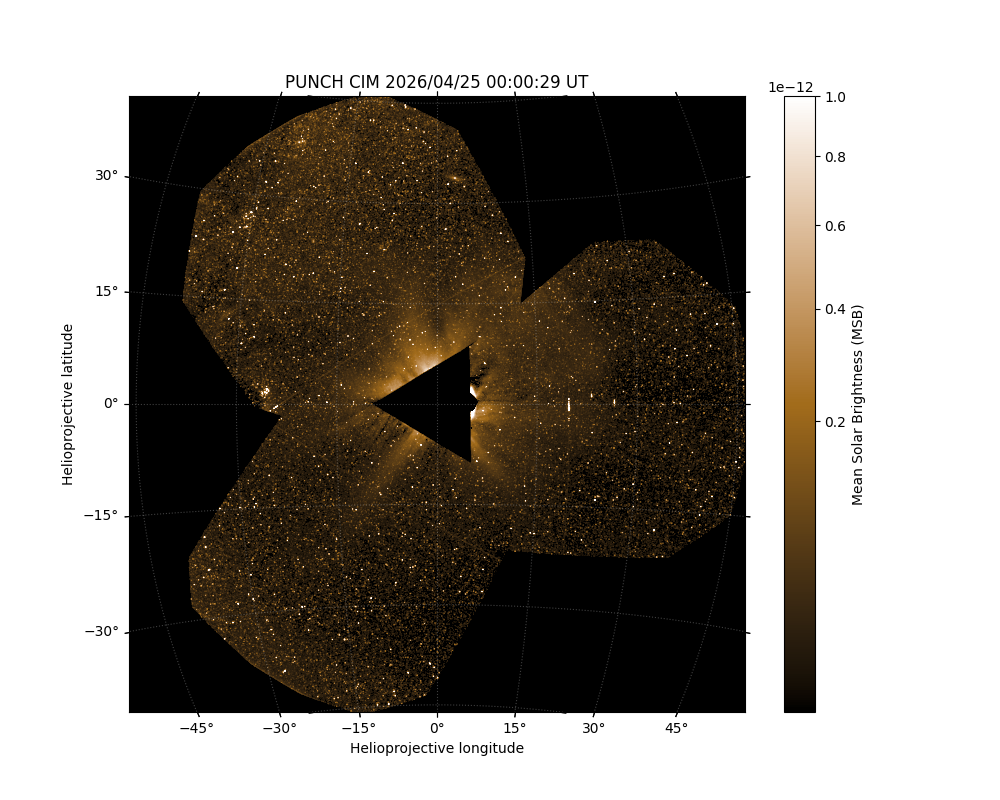

NDCube
------
Shape: (4096, 4096)
Physical Types of Axes: [('custom:pos.helioprojective.lon', 'custom:pos.helioprojective.lat'), ('custom:pos.helioprojective.lon', 'custom:pos.helioprojective.lat')]
Unit: ct
Data Type: float64

In [17]:
# %%
if files:
    fig, ax = visualize.plot_punch(files[0])
plt.show()

# %%
# And that's it! From here the data is loaded into the PUNCH plotting tool and displayed.
# Of course this is just one path, you could always load the data using the punchbowl.data.punch_io.load_ndcube_from_fits() function or Astropy fits tools.
# As an example you could load this file using:

# %%
if files:
    datacube = punch_io.load_ndcube_from_fits(files[0])

datacube

In [22]:
dir(datacube)

['__abstractmethods__',
 '__add__',
 '__array_ufunc__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__extra_coords',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__mul__',
 '__ne__',
 '__neg__',
 '__new__',
 '__pow__',
 '__radd__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__rmul__',
 '__rsub__',
 '__rtruediv__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__sub__',
 '__subclasshook__',
 '__truediv__',
 '__weakref__',
 '_abc_impl',
 '_as_mpl_axes',
 '_data',
 '_extra_coords',
 '_generate_world_coords',
 '_get_crop_by_values_item',
 '_get_crop_item',
 '_global_coords',
 '_handle_wcs_slicing_error',
 '_mask',
 '_meta',
 '_new_instance',
 '_psf',
 '_slice',
 '_slice_mask',
 '_slice_uncertainty',
 '_slice_wcs',
 '_uncertainty',
 '_unit',
 '_wcs',
 'array_axis_physical_typ

In [9]:
# Grab timesteps to add to plots

bottom_decile = np.zeros(len(files))
upper_decile = np.zeros(len(files))
mean_bin = np.zeros(len(files))

bin_center_x = 1000
bin_center_y = 1500
bin_width = 200

for (n, file) in enumerate(files): 
    datacube = punch_io.load_ndcube_from_fits(file)
    new_cube = datacube.data
    new_cube[datacube.mask==True]= np.nan

    cube_slice = new_cube[bin_center_x-200:bin_center_x+200, bin_center_y-200:bin_center_y+200]
    
    mean_bin[n] = np.nanmean(cube_slice)
    bottom_decile[n] = np.nanpercentile(cube_slice, 10)
    upper_decile[n] = np.nanpercentile(cube_slice, 90)

    

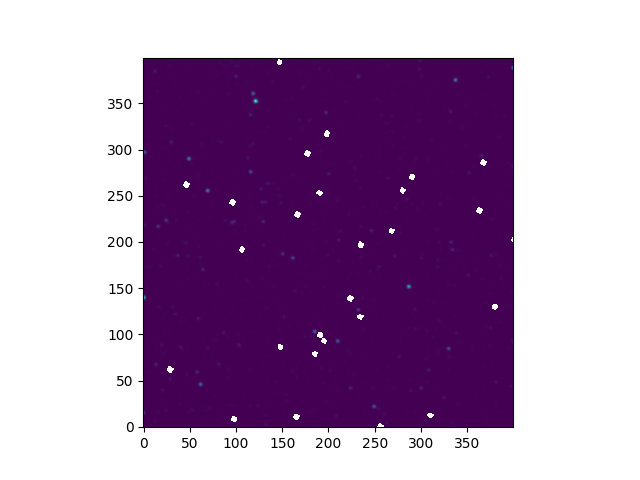

In [10]:
# TODO; find out what the masked dots are... maybe bad pixels

plt.figure()
plt.imshow(cube_slice, origin = 'lower')

In [11]:
np.nanmax(new_cube)

np.float64(2.790282588316373e-11)

In [12]:
upper_decile

array([3.69603545e-14, 3.67696569e-14, 3.49287507e-14, 3.53577173e-14,
       3.44435208e-14, 3.46440731e-14, 3.29033438e-14, 3.89633665e-14,
       3.74017969e-14, 3.74790903e-14, 3.80510612e-14, 3.74730398e-14,
       3.68902740e-14, 3.65262677e-14, 3.50014715e-14, 3.55866683e-14,
       3.49521471e-14, 3.43911233e-14, 3.48850228e-14, 3.89007166e-14,
       3.74438429e-14, 3.83099768e-14, 3.78477374e-14, 3.78953542e-14,
       3.65135202e-14, 3.70417347e-14, 3.62632843e-14, 3.53833360e-14,
       3.41345604e-14, 3.48850587e-14, 3.48905675e-14, 3.90207902e-14,
       3.75516472e-14, 3.77888201e-14, 3.79268428e-14, 3.68810207e-14,
       5.02108737e-14, 3.67859565e-14, 3.67510384e-14, 3.42730435e-14,
       3.48822652e-14, 3.46497225e-14, 3.51368281e-14, 3.77589883e-14,
       3.76419138e-14, 3.79305115e-14, 3.85319577e-14, 3.57872742e-14,
       3.72237065e-14, 3.69128386e-14, 3.72856009e-14, 3.52029359e-14,
       3.46073722e-14, 3.48760192e-14, 3.47103185e-14, 3.36554450e-14,
      

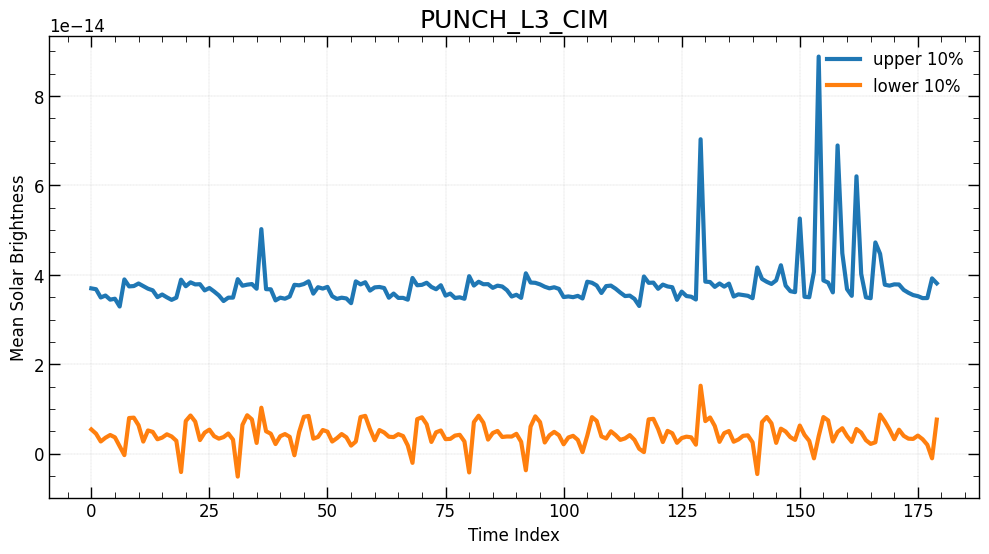

In [23]:

# Look into using a fourier transform noting that this is unevenly sampled data

plt.figure()
plt.plot(upper_decile, label = 'upper 10%')
plt.plot(bottom_decile, label = 'lower 10%')
plt.title('PUNCH_L3_CIM')
plt.xlabel('Time Index')
plt.ylabel('Mean Solar Brightness')
plt.legend()

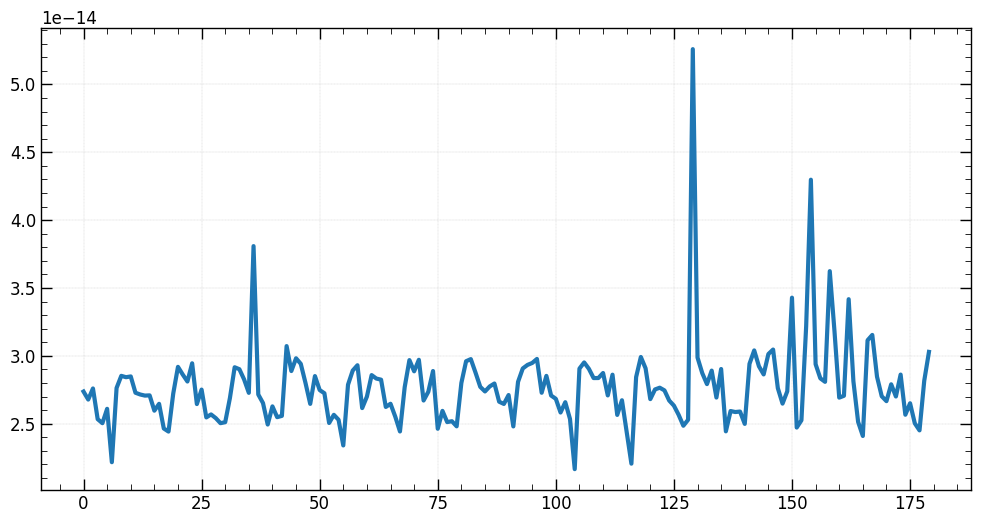

In [20]:
plt.figure()
plt.plot(mean_bin)

In [36]:
new_cube

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(4096, 4096))

In [26]:
datacube.mask[1024,1024]

np.False_

In [33]:
datacube.mask

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]],
      shape=(4096, 4096))